In [1]:
import numpy as np
import pandas as pd
import math
from uncertainties import unumpy as unp
from uncertainties import ufloat as uf
import numpy as np
import uncertainties.umath as umath
import matplotlib.pyplot as plt
from scipy import stats

In [55]:
%%latex

$$R(T) = A_0 \cdot exp(\frac{-C}{T})$$

For $A_0 = 0.0359 \pm 0.0005$  $\Omega$, $C = -3747 \pm 4  $ $K$. In terms of T (K):

$$ T(R) = \frac{C}{ln(\frac{R}{A0})} $$ 


With the linear relation between lenght variation $\Delta L$ ($mm$) and temperature:

$$ \Delta L  = \alpha L_0 \Delta T$$



<IPython.core.display.Latex object>

In [70]:
class info:
    base_length = uf(83.2, 0.1)/10 #mm
    initial_length = uf(0, 0.01) #mm
    initial_resistance = uf(10.84,0.05 )*1000 #ohm

    final_length = uf(0.99, 0.01) #mm
    final_resistance = uf(0.75,0.05 )*1000 #ohm

    A0 = uf(0.0359, 0.0005)
    C = uf(3747, 4)
    def R_to_T(R): #ohm to K
        T = info.C/umath.log(R/info.A0)
        return T
        

raw = pd.read_csv("raw.dat", sep="\t")

print(raw)

    R_kOhm  Length_mm
0    0.745       0.99
1    1.000       0.79
2    1.100       0.74
3    1.200       0.70
4    1.250       0.68
5    1.300       0.66
6    1.400       0.62
7    1.450       0.61
8    1.500       0.59
9    1.600       0.57
10   1.700       0.54
11   1.800       0.52
12   1.900       0.50
13   2.000       0.49
14   2.200       0.45
15   2.500       0.41
16   2.800       0.38
17   3.000       0.36
18   3.500       0.32
19   4.000       0.28
20   4.500       0.25
21   5.000       0.22
22   5.500       0.20
23   6.000       0.17
24   6.500       0.15
25   7.000       0.13


In [71]:
#Simple Alpha determination

T_max = info.R_to_T(info.final_resistance)
T_min = info.R_to_T(info.initial_resistance)
alpha_simple = (info.final_length - info.initial_length)/(info.base_length*(T_max - T_min))

print(alpha_simple)


0.00149+/-0.00005


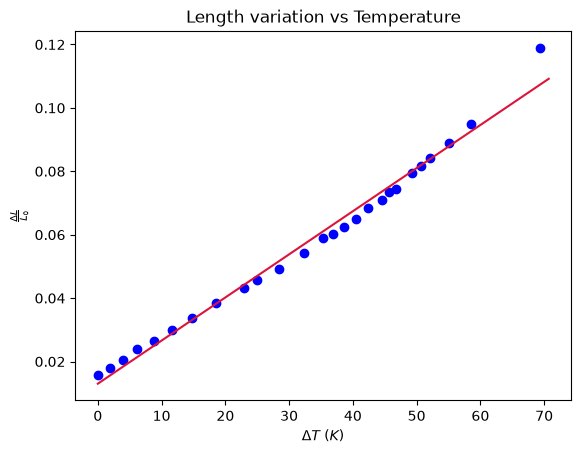

Linear fit for $\alpha$ =  0.001360+/-0.000033


In [64]:
R_arr = raw["R_kOhm"].to_numpy()*1000 #Ohm

T_arr = np.array([])

for R in R_arr:
    T_arr = np.append(T_arr, info.R_to_T(R).nominal_value)

DLength = raw["Length_mm"].to_numpy()/info.base_length.nominal_value #mm

Delta_T = T_arr - T_arr.min()

reg = stats.linregress(Delta_T, DLength)

x_line = np.linspace(Delta_T.min()*0.98, Delta_T.max()*1.02)
y_line = x_line*reg.slope + reg.intercept

alpha = uf(reg.slope, reg.stderr)


plt.scatter(Delta_T, DLength, color="blue")
plt.plot(x_line, y_line, color="crimson")

plt.xlabel(r"$\Delta T$ ($K$)")
plt.ylabel(r"$\frac{\Delta L}{L_0}$")
plt.title(r"Length variation vs Temperature")

plt.show()

print(r"Linear fit for $\alpha$ = ", alpha)
